# Advanced Analytics + Risk Metrics

This notebook implements the assigned advanced analytics tasks using the cleaned processed datasets.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = Path.cwd().resolve()
DATA = BASE.parent / "data" / "processed" if (BASE.name == "notebooks") else BASE / "data" / "processed"

nav = pd.read_csv(DATA / "02_nav_history_processed.csv", parse_dates=["date"])
funds = pd.read_csv(DATA / "01_fund_master_processed.csv")
tx = pd.read_csv(DATA / "08_investor_transactions_processed.csv", parse_dates=["transaction_date"])
perf = pd.read_csv(DATA / "07_scheme_performance_processed.csv")
hold = pd.read_csv(DATA / "09_portfolio_holdings_processed.csv", parse_dates=["portfolio_date"])

nav = nav.sort_values(["amfi_code","date"])
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()
print("NAV rows:", len(nav), "| Funds:", nav["amfi_code"].nunique())

NAV rows: 46000 | Funds: 40


## 1. Historical VaR and CVaR (95%)
VaR is the 5th percentile of daily returns. CVaR is the mean return on days at or below the VaR threshold.

In [2]:
rows=[]
for code, g in nav.groupby("amfi_code"):
    r=g["daily_return"].dropna()
    var95=r.quantile(0.05)
    cvar95=r[r <= var95].mean()
    rows.append([code,var95,cvar95,len(r)])
var_cvar=pd.DataFrame(rows,columns=["amfi_code","VaR_95","CVaR_95","Return_Observations"])
var_cvar=var_cvar.merge(funds[["amfi_code","scheme_name","fund_house","category","risk_category"]],on="amfi_code",how="left")
var_cvar["VaR_95_pct"]=var_cvar["VaR_95"]*100
var_cvar["CVaR_95_pct"]=var_cvar["CVaR_95"]*100
display(var_cvar.sort_values("VaR_95").head(10))

,amfi_code,VaR_95,CVaR_95,Return_Observations,scheme_name,fund_house,category,risk_category,VaR_95_pct,CVaR_95_pct
22,119599,-0.026859,-0.032384,1149,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Equity,Very High,-2.685944,-3.238412
17,119095,-0.026188,-0.031667,1149,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,Equity,Very High,-2.618842,-3.166729
4,101207,-0.026021,-0.032459,1149,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity,Very High,-2.602125,-3.245906
11,118634,-0.025438,-0.032304,1149,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,Equity,Very High,-2.543811,-3.230407
21,119598,-0.024507,-0.030595,1149,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,Very High,-2.450705,-3.059526
39,149324,-0.023483,-0.031036,1149,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Equity,Very High,-2.348307,-3.103625
7,102886,-0.019220,-0.023251,1149,UTI Mid Cap Fund - Regular - Growth,UTI Mutual Fund,Equity,High,-1.922028,-2.325086
2,100033,-0.019034,-0.023456,1149,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Equity,High,-1.903354,-2.345576
25,120505,-0.018892,-0.024342,1149,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity,High,-1.889179,-2.434207
16,119094,-0.018480,-0.024260,1149,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Equity,High,-1.848028,-2.426006


## 2. Rolling 90-Day Sharpe
Formula: rolling mean / rolling standard deviation × √252.

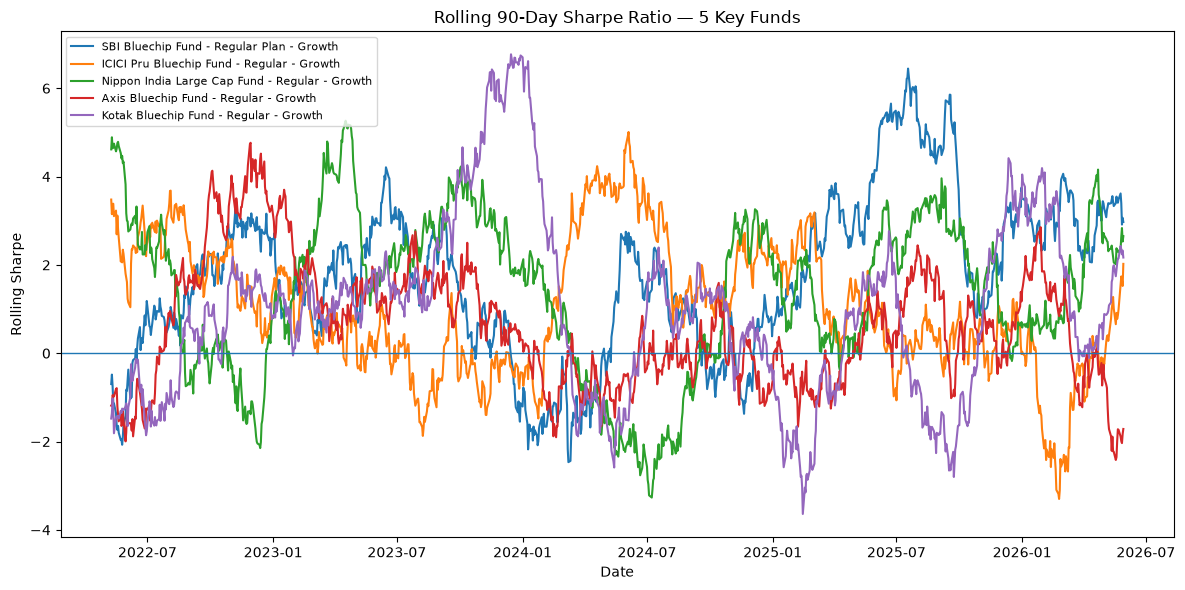

In [3]:
key_codes=[119551,120503,118632,119092,120841]
names=dict(zip(funds["amfi_code"],funds["scheme_name"]))
plt.figure(figsize=(12,6))
for code in key_codes:
    g=nav[nav["amfi_code"]==code].sort_values("date").copy()
    rs=g["daily_return"].rolling(90).mean()/g["daily_return"].rolling(90).std()*np.sqrt(252)
    plt.plot(g["date"],rs,label=names.get(code,str(code)))
plt.axhline(0,linewidth=1)
plt.title("Rolling 90-Day Sharpe Ratio — 5 Key Funds")
plt.xlabel("Date"); plt.ylabel("Rolling Sharpe"); plt.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 3. Investor Cohort Analysis
Cohorts are grouped by each investor's first transaction year. For SIP cohorts, the notebook reports average SIP amount, total SIP investment, and the top SIP fund by amount.

In [4]:
tx["cohort_year"]=tx.groupby("investor_id")["transaction_date"].transform("min").dt.year
cohort_base=tx.groupby("cohort_year").agg(investors=("investor_id","nunique")).reset_index()
sip=tx[tx["transaction_type"].astype(str).str.casefold()=="sip"].copy()
cohort_sip=sip.groupby("cohort_year").agg(
    avg_sip_amount_inr=("amount_inr","mean"),
    total_sip_invested_inr=("amount_inr","sum")
).reset_index()
pref=(sip.groupby(["cohort_year","amfi_code"])["amount_inr"].sum().reset_index()
      .sort_values(["cohort_year","amount_inr"],ascending=[True,False])
      .drop_duplicates("cohort_year")
      .merge(funds[["amfi_code","scheme_name"]],on="amfi_code",how="left"))
cohort_analysis=cohort_base.merge(cohort_sip,on="cohort_year",how="left").merge(
    pref[["cohort_year","scheme_name"]].rename(columns={"scheme_name":"top_sip_fund"}),on="cohort_year",how="left")
display(cohort_analysis)

,cohort_year,investors,avg_sip_amount_inr,total_sip_invested_inr,top_sip_fund
0,2024,4803,10996.885825,214978121,HDFC Mid-Cap Opportunities Fund - Direct - Growth
1,2025,197,13505.209581,2255370,SBI Small Cap Fund - Direct Plan - Growth


## 4. SIP Continuity Analysis
Only investors with 6+ SIP transactions are included. Average gap and maximum gap are calculated; investors with any gap above 35 days are flagged as at-risk.

In [5]:
sip=sip.sort_values(["investor_id","transaction_date"]).copy()
eligible=sip.groupby("investor_id").size()
eligible_ids=eligible[eligible>=6].index
s=sip[sip["investor_id"].isin(eligible_ids)].copy()
s["gap_days"]=s.groupby("investor_id")["transaction_date"].diff().dt.days
continuity=s.groupby("investor_id").agg(
    sip_transactions=("transaction_date","size"),
    avg_gap_days=("gap_days","mean"),
    max_gap_days=("gap_days","max")
).reset_index()
continuity["at_risk"]=continuity["max_gap_days"]>35
display(continuity.head())
print("Eligible investors:",len(continuity),"At-risk:",int(continuity["at_risk"].sum()),
      f"({continuity['at_risk'].mean()*100:.1f}%)")

,investor_id,sip_transactions,avg_gap_days,max_gap_days,at_risk
0,INV000004,6,85.400000,265.0,True
1,INV000008,6,70.400000,165.0,True
2,INV000010,6,64.800000,139.0,True
3,INV000011,7,40.166667,125.0,True
4,INV000012,8,57.000000,132.0,True


Eligible investors: 1362 At-risk: 1361 (99.9%)


## 5. Simple Fund Recommender
For Low/Moderate/High risk appetite, return the top 3 funds by Sharpe ratio within the exact matching risk grade.

In [6]:
def recommend(risk_appetite, top_n=3):
    valid={"Low","Moderate","High"}
    if risk_appetite not in valid: raise ValueError(f"Choose one of {sorted(valid)}")
    return (perf[perf["risk_grade"].astype(str).str.casefold()==risk_appetite.casefold()]
            .sort_values("sharpe_ratio",ascending=False).head(top_n)
            [["scheme_name","fund_house","category","risk_grade","sharpe_ratio","return_3yr_pct","max_drawdown_pct"]])
for risk in ["Low","Moderate","High"]:
    print("\n",risk); display(recommend(risk))


 Low


,scheme_name,fund_house,category,risk_grade,sharpe_ratio,return_3yr_pct,max_drawdown_pct
14,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Liquid,Low,7.68,7.68,-2.62
23,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,Liquid,Low,6.18,6.18,-3.81
30,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,Liquid,Low,5.14,5.14,-3.66



 Moderate


,scheme_name,fund_house,category,risk_grade,sharpe_ratio,return_3yr_pct,max_drawdown_pct
5,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,Moderate,1.06,14.84,-17.41
34,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,Moderate,1.06,14.81,-17.07
11,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Large Cap,Moderate,1.03,14.41,-26.59



 High


,scheme_name,fund_house,category,risk_grade,sharpe_ratio,return_3yr_pct,max_drawdown_pct
21,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,Mid Cap,High,0.96,18.23,-21.92
12,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Mid Cap,High,0.95,18.08,-21.84
38,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Mid Cap,High,0.90,17.16,-26.99


## 6. Sector HHI Concentration
For equity funds, HHI = Σ(weight_pct²). Higher HHI indicates a more concentrated sector allocation.

In [7]:
equity_codes=set(funds.loc[funds["category"].astype(str).str.contains("Equity",case=False,na=False),"amfi_code"])
eh=hold[hold["amfi_code"].isin(equity_codes)].copy()
hhi=eh.groupby("amfi_code")["weight_pct"].apply(lambda x:(x**2).sum()).reset_index(name="sector_hhi")
hhi=hhi.merge(funds[["amfi_code","scheme_name","fund_house"]],on="amfi_code",how="left").sort_values("sector_hhi",ascending=False)
display(hhi.head(10))

,amfi_code,sector_hhi,scheme_name,fund_house
11,119092,2064.4767,Axis Bluechip Fund - Regular - Growth,Axis Mutual Fund
3,101207,2007.0043,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF
18,119599,1747.5096,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund
4,102885,1747.0902,UTI Nifty 50 Index Fund - Regular - Growth,UTI Mutual Fund
7,118632,1682.9820,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF
29,148568,1679.2973,Mirae Asset Emerging Bluechip Fund - Regular -...,Mirae Asset MF
21,120505,1575.7036,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF
22,120506,1537.9360,ICICI Pru Value Discovery Fund - Regular - Growth,ICICI Prudential MF
27,125498,1524.1398,HDFC Mid-Cap Opportunities Fund - Direct - Growth,HDFC Mutual Fund
23,120841,1496.8035,Kotak Bluechip Fund - Regular - Growth,Kotak Mahindra MF


## 7. Advanced Insights
- VaR/CVaR provide downside-loss estimates directly from the observed daily NAV return distribution.
- Rolling Sharpe reveals changes in risk-adjusted performance rather than only a single full-period ratio.
- Investor cohorts in the supplied transaction data begin in the years represented by first transaction dates; cohort comparisons therefore reflect the available transaction window.
- SIP continuity flags investors with a gap above 35 days among investors with at least six SIPs.
- HHI identifies equity funds whose sector weights are concentrated rather than evenly distributed.